# Dense Autoencoder Training

This notebook converts stored time-series samples (T, F) into dense vectors (D,) and trains a Dense Autoencoder (DenseAE).
It mirrors the demo flow used in `test.ipynb` but flattens samples and builds `mode='dense'` models. Use the smoke-run at the end for a short verification run.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
human_in_the_loop_root = Path().absolute().parent
os.chdir(human_in_the_loop_root)
print('CWD:', Path().absolute())

CWD: /home/agaros/mywork/NWDAF-Anomaly-Detection/human_in_the_loop


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from artifact_experiment.tracking import DataSplit, FilesystemTrackingClient
from artifact_torch.binary_classification import BinaryClassSpec, BinaryClassStore, BinaryClassificationRoutineData
from artifact_torch.nn import DataLoader

from hitl.experiment.experiment import DemoBinaryClassificationExperiment
from hitl.models.ae_artifact_ml import FilterModel
from hitl.models.ae import build_model, model_summary
from hitl.experiment.data.dataset import FilterModelClassifierDataset
from hitl.store.sqlite import SQLite
from hitl.store.repository import Repository
from hitl.io.serialization import decode_npy

sns.set_theme(style="whitegrid")

In [4]:
# Experiment / label config
from hitl.config import (
    EXPERIMENT_ID,
    VAL_DATA_PROPORTION,
    POSITIVE_CLASS,
    NEGATIVE_CLASS,
    CLASSNAMES,
    LABEL_FEATURE,
    SCHEMA_ID,
    BATCH_SIZE,
    LATENT_DIM,
    THRESHOLD_CALC_BATCH_SIZE,
    CLASSIFICATION_THRESHOLD
)


In [5]:
# DB / repository setup
db_path = human_in_the_loop_root / "db" / "hitl.db"
sqlite_store = SQLite(path=str(db_path))
repo = Repository(sqlite_store)
print('Repository ready')

Repository ready


In [6]:
# Diagnostic: list available schemas and vector counts
schemas = repo.list_schemas()
print('Schemas found:', len(schemas))
for s in schemas[:20]:
    sid = s['schema_id']
    cnt = repo.count_vectors(sid)
    print(f'- {sid} -> {cnt} vectors')

Schemas found: 1
- 67b4d11c626dc4c211ff758c0667e294ac3fb145 -> 18571 vectors


In [7]:
def load_training_dataset_from_repo(repo, schema_id: str, only_false_positives: bool = True):
    """Load vectors from the Repository into (N, T, F) arrays and related metadata.
    Returns: X (N,T,F), ids (list), storage_sample_shape (T,F), labels (list), all (dict id->(arr,label))
    """
    vectors = []
    ids = []
    labels = []
    all_dict = {}
    for anomaly_id, blob in repo.iter_vectors(schema_id):
        fb = repo.latest_feedback(anomaly_id)
        if only_false_positives:
            if not fb or fb["label"] != "FP":
                continue
        else:
            if not fb or fb["label"] not in ["TP", "FP"]:
                continue
        arr = decode_npy(blob)
        if getattr(arr, "ndim", None) != 2:
            raise ValueError(f'Expected 2D array for conv1d storage format (T,F), got ndim={getattr(arr, "ndim", None)}')
        vectors.append(arr)
        ids.append(anomaly_id)
        labels.append(fb["label"])
        all_dict[str(anomaly_id)] = (arr, fb["label"])
    if not vectors:
        raise ValueError(f'No vectors found for schema {schema_id}')
    X = np.stack(vectors, axis=0)
    storage_sample_shape = X.shape[1:]
    return X, ids, storage_sample_shape, labels, all_dict

In [8]:
# Specify schema_id to load (use same schema id you used in test.ipynb)
X, ids, storage_sample_shape, labels, all_dict = load_training_dataset_from_repo(repo, SCHEMA_ID, only_false_positives=False)
print('Loaded X shape (N, T, F):', X.shape)
print('storage_sample_shape (T,F):', storage_sample_shape)

Loaded X shape (N, T, F): (18571, 12, 8)
storage_sample_shape (T,F): (12, 8)


In [9]:
# Split FP/TP into train (FP-only) and validation (FP subset + all TPs)
def split_fp_tp(all_data, fp_val_percentage: float, rng: np.random.Generator | None = None):
    if rng is None:
        rng = np.random.default_rng()
    fp_ids = [sid for sid, (_, label) in all_data.items() if label == "FP"]
    tp_ids = [sid for sid, (_, label) in all_data.items() if label == "TP"]
    n_fp = len(fp_ids)
    n_fp_val = int(np.floor(n_fp * fp_val_percentage))
    fp_ids_array = np.array(fp_ids)
    rng.shuffle(fp_ids_array)
    fp_val_ids = set(fp_ids_array[:n_fp_val])
    fp_train_ids = set(fp_ids_array[n_fp_val:])
    train_fp_only = { sid: all_data[sid] for sid in fp_train_ids }
    val_ids = fp_val_ids.union(tp_ids)
    val_fp_and_tp = { sid: all_data[sid] for sid in val_ids }
    return train_fp_only, val_fp_and_tp

train_set, validation_set = split_fp_tp(all_dict, fp_val_percentage=VAL_DATA_PROPORTION)
print('Train/Val sizes:', len(train_set), len(validation_set))

Train/Val sizes: 11800 6771


In [10]:
# for the validation set, give me how many are FP vs TP
val_fp_count = sum(1 for _, label in validation_set.values() if label == "FP")
val_tp_count = sum(1 for _, label in validation_set.values() if label == "TP")
print('Validation set - FP count:', val_fp_count, 'TP count:', val_tp_count)

Validation set - FP count: 2950 TP count: 3821


In [11]:
# Stack arrays (N, T, F) for train and validation
arrays = {
    DataSplit.TRAIN: np.stack([entry[0] for entry in train_set.values()]) if train_set else np.empty((0,) + X.shape[1:], dtype=np.float32),
    DataSplit.VALIDATION: np.stack([entry[0] for entry in validation_set.values()]) if validation_set else np.empty((0,) + X.shape[1:], dtype=np.float32),
}
print('arrays shapes (train, val):', arrays[DataSplit.TRAIN].shape, arrays[DataSplit.VALIDATION].shape)

arrays shapes (train, val): (11800, 12, 8) (6771, 12, 8)


In [12]:
# Convert to dense by flattening each (T, F) sample -> (D,) where D = T*F
arrays_dense = { ds: (arr.reshape((arr.shape[0], -1)) if arr.ndim == 3 and arr.shape[0] > 0 else np.empty((0, 0), dtype=np.float32)) for ds, arr in arrays.items() }
D = arrays_dense[DataSplit.TRAIN].shape[1] if arrays_dense[DataSplit.TRAIN].size else (arrays_dense[DataSplit.VALIDATION].shape[1] if arrays_dense[DataSplit.VALIDATION].size else 0)
print('Dense shapes (train, val):', arrays_dense[DataSplit.TRAIN].shape, arrays_dense[DataSplit.VALIDATION].shape, 'D=', D)
assert D > 0, 'No data available to build dense model'

Dense shapes (train, val): (11800, 96) (6771, 96) D= 96


In [13]:
# Build datasets and dataloaders (expecting (N, D))
datasets = { data_split: FilterModelClassifierDataset(input_array=array) for data_split, array in arrays_dense.items() }
data_loaders = { data_split: DataLoader(dataset=dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True) for data_split, dataset in datasets.items() }
print('DataLoaders ready')

DataLoaders ready


In [14]:
# Build a Dense autoencoder

hidden_dims = [D // 2, D // 4]
dense_model = build_model(mode="dense", input_shape=(D,), hidden_dims=hidden_dims, latent_dim=LATENT_DIM)
print(model_summary(dense_model, input_shape=(D,)))
filter_model = FilterModel(model=dense_model)

Model: DenseAE
Layer (type)                   Output Shape              Param #        
Linear                         (1, 48)                   4,656          
ReLU                           (1, 48)                   0              
Linear                         (1, 24)                   1,176          
ReLU                           (1, 24)                   0              
Linear                         (1, 12)                   300            
Linear                         (1, 24)                   312            
ReLU                           (1, 24)                   0              
Linear                         (1, 48)                   1,200          
ReLU                           (1, 48)                   0              
Linear                         (1, 96)                   4,704          
Total params: 12,348
Trainable params: 12,348
Non-trainable params: 0


In [15]:
# Prepare artifact routine data (true label stores)
def _map_labels(label):
    if label == "FP":
        return NEGATIVE_CLASS
    elif label == "TP":
        return POSITIVE_CLASS
    else:
        raise ValueError(f'Unknown label: {label}')

# Build id->class mappings
id_to_class_true_train = { sid: _map_labels(label) for sid, (_, label) in train_set.items() }
id_to_class_true_val = { sid: _map_labels(label) for sid, (_, label) in validation_set.items() }
class_spec = BinaryClassSpec(class_names=CLASSNAMES, positive_class=POSITIVE_CLASS, label_name=LABEL_FEATURE)
true_label_stores = {
    DataSplit.TRAIN: BinaryClassStore.from_class_names_and_spec(class_spec=class_spec, id_to_class=id_to_class_true_train),
    DataSplit.VALIDATION: BinaryClassStore.from_class_names_and_spec(class_spec=class_spec, id_to_class=id_to_class_true_val),
}
# Build flattened classification_data mappings for Dense model (per-sample dense vectors)
id_to_data_train_dense = { sid: features.reshape(-1) for sid, (features, _) in train_set.items() }
id_to_data_val_dense = { sid: features.reshape(-1) for sid, (features, _) in validation_set.items() }

artifact_routine_data = {
    DataSplit.TRAIN: BinaryClassificationRoutineData(true_class_store=true_label_stores[DataSplit.TRAIN], classification_data=id_to_data_train_dense),
    DataSplit.VALIDATION: BinaryClassificationRoutineData(true_class_store=true_label_stores[DataSplit.VALIDATION], classification_data=id_to_data_val_dense),
}
# Build tracking client and experiment
tracking_client = FilesystemTrackingClient.build(experiment_id=EXPERIMENT_ID)
experiment = DemoBinaryClassificationExperiment.build(
    model=filter_model,
    data_loaders=data_loaders,
    artifact_routine_data=artifact_routine_data,
    artifact_routine_data_spec=class_spec,
    tracking_client=tracking_client,
)
print('Experiment built')

Experiment built


In [16]:
experiment.run()

Training on device: cuda


                                                                          /home/agaros/mywork/NWDAF-Anomaly-Detection/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/agaros/mywork/NWDAF-Anomaly-Detection/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/agaros/mywork/NWDAF-Anomaly-Detection/venv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/agaros/mywork/NW

In [19]:
import torch
import json

# Create models directory if it doesn't exist
save_dir = human_in_the_loop_root / "saved_models"
save_dir.mkdir(exist_ok=True)

# Calculate threshold from training data (reconstruction error distribution)
print("Calculating threshold from training data...")
dense_model.eval()

# Get the device the model is on
device = next(dense_model.parameters()).device
print(f"Model is on device: {device}")

# Use the raw array directly
train_data_tensor = torch.from_numpy(arrays_dense[DataSplit.TRAIN]).float()
train_errors = []

with torch.no_grad():
    for i in range(0, len(train_data_tensor), THRESHOLD_CALC_BATCH_SIZE):
        batch = train_data_tensor[i:i+THRESHOLD_CALC_BATCH_SIZE].to(device)
        recon = dense_model(batch)
        mse = torch.mean((batch - recon) ** 2, dim=1)
        train_errors.append(mse.cpu().numpy())

if train_errors:
    train_errors = np.concatenate(train_errors)
    # Calculate threshold based on the percentile defined in the experiment config
    # CLASSIFICATION_THRESHOLD is a probability (0-1), so we convert to percentile (0-100)
    percentile = CLASSIFICATION_THRESHOLD * 100
    threshold = float(np.percentile(train_errors, percentile))
    print(f"Calculated threshold ({percentile}th percentile): {threshold}")
else:
    print("Warning: No training data to calculate threshold. Using default 0.5")
    threshold = 0.5

# Save model weights
model_path = save_dir / "dense_autoencoder.pth"
torch.save(dense_model.state_dict(), model_path)
print(f"Model saved to {model_path}")

# Save model configuration
config = {
    "input_dim": D,
    "hidden_dims": hidden_dims,
    "latent_dim": LATENT_DIM,
    "mode": "dense",
    "threshold": threshold
}
config_path = save_dir / "dense_autoencoder_config.json"
with open(config_path, "w") as f:
    json.dump(config, f)
print(f"Config saved to {config_path}")

Calculating threshold from training data...
Model is on device: cuda:0
Calculated threshold (56.99999999999999th percentile): 0.9212926626205444
Model saved to /home/agaros/mywork/NWDAF-Anomaly-Detection/human_in_the_loop/saved_models/dense_autoencoder.pth
Config saved to /home/agaros/mywork/NWDAF-Anomaly-Detection/human_in_the_loop/saved_models/dense_autoencoder_config.json


In [36]:
# load the model and run inference and results in the validaton set

# Add the project root to sys.path if not already there to ensure imports work
import sys
if str(human_in_the_loop_root) not in sys.path:
    sys.path.append(str(human_in_the_loop_root))

from privateer_filter_inference.inference_dense import predict

print("Running inference on validation set...")
results = predict(
    data=arrays_dense[DataSplit.VALIDATION],
    # model_dir=save_dir
)

# Display first few results
print(f"Inference complete. Processed {len(results)} samples.")
print(f"Threshold used: {results[0]['threshold']:.6f}")

anomalies = [r for r in results if r['is_anomaly']]
print(f"Found {len(anomalies)} anomalies out of {len(results)} validation samples ({len(anomalies)/len(results)*100:.2f}%)")

if results:
    print("\nSample result:")
    print(results[0])

Running inference on validation set...
Inference complete. Processed 6771 samples.
Threshold used: 0.921293
Found 4443 anomalies out of 6771 validation samples (65.62%)

Sample result:
{'is_anomaly': False, 'score': 0.8394457697868347, 'threshold': 0.9212926626205444}


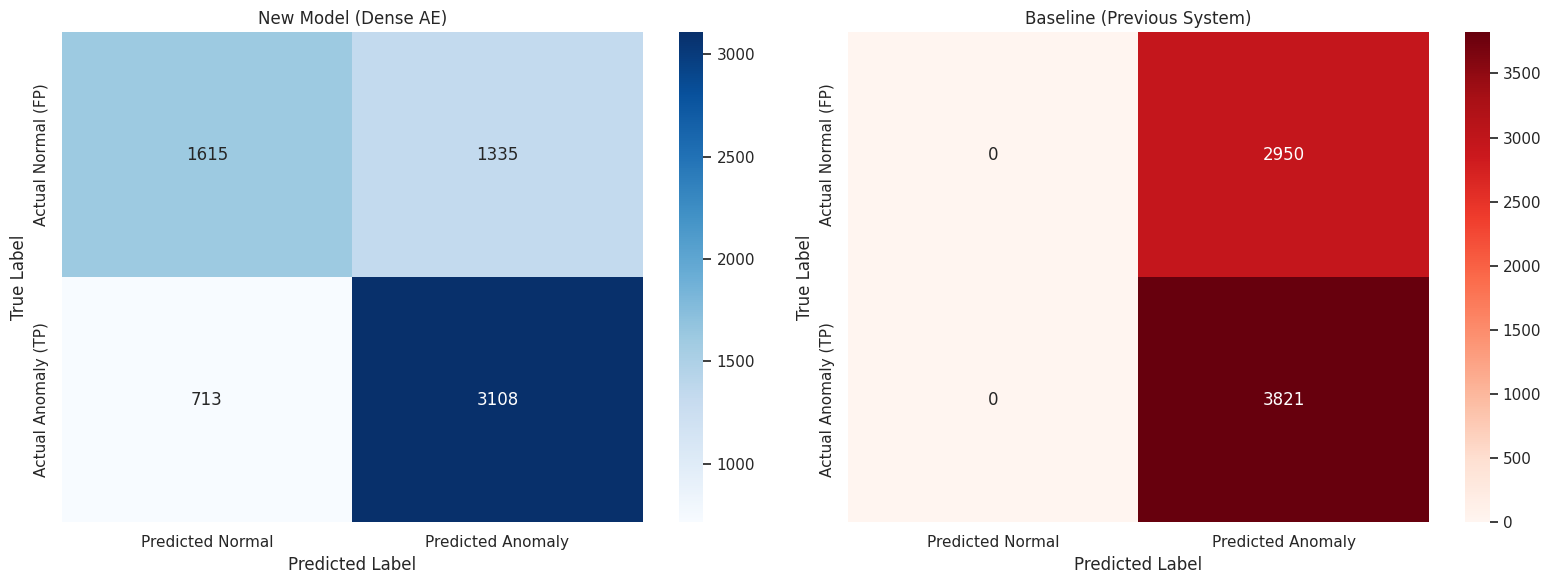

NEW MODEL PERFORMANCE
              precision    recall  f1-score   support

 Normal (FP)       0.69      0.55      0.61      2950
Anomaly (TP)       0.70      0.81      0.75      3821

    accuracy                           0.70      6771
   macro avg       0.70      0.68      0.68      6771
weighted avg       0.70      0.70      0.69      6771


BASELINE PERFORMANCE (Previous System)
              precision    recall  f1-score   support

 Normal (FP)       0.00      0.00      0.00      2950
Anomaly (TP)       0.56      1.00      0.72      3821

    accuracy                           0.56      6771
   macro avg       0.28      0.50      0.36      6771
weighted avg       0.32      0.56      0.41      6771


Correlation between Reconstruction Error and True Label: 0.3844

IMPROVEMENT SUMMARY
False Positives (Noise): 2950 -> 1335 (Reduced by 54.7%)
True Positives (Real):   3821 -> 3108 (Retained 81.3%)


In [37]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Extract true labels from validation_set
# Note: validation_set.values() order matches the arrays_dense[DataSplit.VALIDATION] order
# FP (False Positive from previous system) is considered Normal (0) in this context
# TP (True Positive from previous system) is considered Anomaly (1) in this context
y_true = [1 if label == "TP" else 0 for _, label in validation_set.values()]

# Extract predicted labels from results
y_pred = [1 if r['is_anomaly'] else 0 for r in results]

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal (FP)', 'Actual Anomaly (TP)'])
plt.title('New Model (Dense AE)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# --- Baseline Comparison ---
# The previous system flagged ALL these samples as anomalies (that's why they are in the dataset)
y_pred_baseline = [1] * len(y_true)
cm_baseline = confusion_matrix(y_true, y_pred_baseline)

plt.subplot(1, 2, 2)
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal (FP)', 'Actual Anomaly (TP)'])
plt.title('Baseline (Previous System)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Print Classification Reports
print("="*60)
print("NEW MODEL PERFORMANCE")
print("="*60)
print(classification_report(y_true, y_pred, target_names=['Normal (FP)', 'Anomaly (TP)']))

print("\n" + "="*60)
print("BASELINE PERFORMANCE (Previous System)")
print("="*60)
print(classification_report(y_true, y_pred_baseline, target_names=['Normal (FP)', 'Anomaly (TP)'], zero_division=0))

# Calculate correlation between reconstruction error and true label
y_scores = [r['score'] for r in results]
correlation = np.corrcoef(y_true, y_scores)[0, 1]
print(f"\nCorrelation between Reconstruction Error and True Label: {correlation:.4f}")

# --- Improvement Summary ---
fp_baseline = cm_baseline[0, 1] # Actual Normal, Predicted Anomaly
fp_new = cm[0, 1]
reduction = fp_baseline - fp_new
percent_reduction = (reduction / fp_baseline) * 100 if fp_baseline > 0 else 0

tp_baseline = cm_baseline[1, 1]
tp_new = cm[1, 1]
tp_retention = (tp_new / tp_baseline) * 100 if tp_baseline > 0 else 0

print("\n" + "="*60)
print("IMPROVEMENT SUMMARY")
print("="*60)
print(f"False Positives (Noise): {fp_baseline} -> {fp_new} (Reduced by {percent_reduction:.1f}%)")
print(f"True Positives (Real):   {tp_baseline} -> {tp_new} (Retained {tp_retention:.1f}%)")
print("="*60)